# LSTM

## Import libraries

In [43]:
import ccxt
from datetime import datetime
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Huber
import matplotlib.pyplot as plt
import seaborn as sns

## Constants

In [44]:
TIMEFRAME_DICT = {
    "1m": 60 * 1000,
    "5m": 5 * 60 * 1000,
    "15m": 15 * 60 * 1000,
    "1h": 60 * 60 * 1000,
    "1d": 24 * 60 * 60 * 1000,
}

FREQ_DICT = {
    "1m": "T",
    "5m": "5T",
    "15m": "15T",
    "1h": "h",
    "1d": "D",
}

Y_OUTPUT_DICT = {
    "log_return_close": False,
    "bin_return_close": True,
    "bin_return_d2d_close": True,
}

In [45]:
CLIENT = ccxt.binance()
TICKER = "BTC/USDT"
END_DATE = CLIENT.parse8601("2026-03-31T20:00:00Z")
START_DATE = CLIENT.parse8601("2023-11-03T20:00:00Z")
TIMEFRAME = "1h"
LAGS_NUM = 240
TRAIN_TEST_SPLIT_RATIO = 0.7
HIDDEN_NEURONS_NUM = 50
EPOCHS_NUM = 100
BATCH_SIZE = 32
DROPOUT_RATE = 0.2
PATIENCE_NUM = 10
SCALER_BOOLEAN = False
OUTPUT_VALUE = 'bin_return_d2d_close'
BINARY_CLASSIFICATION = Y_OUTPUT_DICT[OUTPUT_VALUE]

## Fetching data

In [46]:
def fetch_data(client, ticker, start_date, end_date, timeframe):
    data = []
    while start_date < end_date:
        limit = 1000 if end_date - start_date >= TIMEFRAME_DICT[timeframe] * 1000 else (end_date - start_date) // (TIMEFRAME_DICT[timeframe])
        if limit <= 0:
            break
        data = data + client.fetch_ohlcv(
            ticker,
            timeframe=timeframe,
            since=start_date,
            limit=limit,
        )
        
        start_date = data[-1][0] + TIMEFRAME_DICT[timeframe] - 1 # -1 to avoid duplicates
    return data

def preprocess_data(data):
    data = pd.DataFrame(
        data,
        columns=["Date", "Open", "High", "Low", "Close", "Volume"]
    )
    # data = data.where(data["Date"] <= END_DATE + 4 * TIMEFRAME_DICT["1h"]).dropna()
    data["Date"] = pd.to_datetime(data["Date"], unit="ms")
    data = data.set_index("Date")
    return data

In [47]:
data = fetch_data(CLIENT, TICKER, START_DATE, END_DATE, TIMEFRAME)
data = preprocess_data(data)
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2023-11-03 20:00:00,34530.71,34659.66,34485.65,34593.90,1046.24789
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035


### Verifying continuous of data

In [48]:
all_dates = pd.date_range(start=data.index.min(), end=data.index.max(), freq=FREQ_DICT[TIMEFRAME])
missing = all_dates.difference(data.index)
print(len(missing), missing)   # 0 => none missing dates

0 DatetimeIndex([], dtype='datetime64[ms]', freq='h')


## Processing data

In [49]:
data['log_return_close'] = np.log(data['Close'] / data['Close'].shift(1))
data['return_close'] = data['Close'] / data['Close'].shift(1) - 1
data['bin_return_close'] = (data['log_return_close'] > 0).astype(int)
data['bin_return_d2d_close'] = (data['log_return_close'] > data['log_return_close'].shift(1)).astype(int)

In [50]:
data = data.dropna()
data.head()

,Open,High,Low,Close,Volume,log_return_close,return_close,bin_return_close,bin_return_d2d_close
Date,,,,,,,,,
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031,0.000203,0.000203,1,0
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337,0.000786,0.000786,1,1
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032,0.002556,0.002560,1,1
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035,-0.000580,-0.000580,0,0
2023-11-04 01:00:00,34696.66,34786.68,34632.47,34768.15,724.86868,0.002059,0.002061,1,1


## Spliting data

In [51]:
X = data.drop(columns=['High', 'Low', 'Open', 'Close', 'Volume', 'bin_return_close', 'bin_return_d2d_close'])
y = data.drop(columns=['High', 'Low', 'Open', 'Close', 'Volume', 'log_return_close'])

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1-TRAIN_TEST_SPLIT_RATIO, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, shuffle=False)
X_backtest, y_backtest = X_test.copy(), y_test.copy()

Overall probability of bin_return_d2d_close being the same as bin_return_close:
0.774


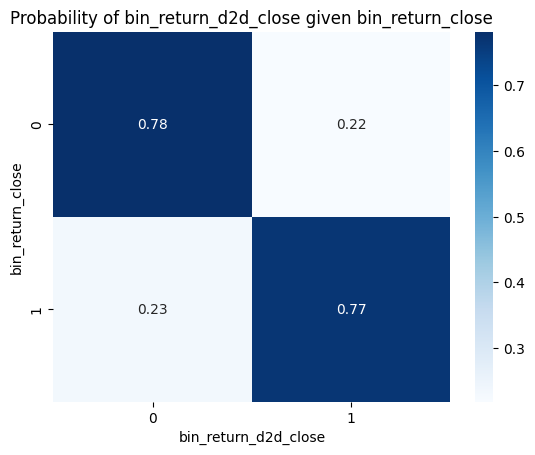

In [53]:
probs = pd.crosstab(
    y_train['bin_return_close'],
    y_train['bin_return_d2d_close'],
    normalize='index'
)
overall_prob = (y_train['bin_return_close'] == y_train['bin_return_d2d_close']).mean()
print("Overall probability of bin_return_d2d_close being the same as bin_return_close:\n{:.3f}".format(overall_prob))
sns.heatmap(probs, annot=True, fmt=".2f", cmap="Blues")
plt.title("Probability of bin_return_d2d_close given bin_return_close")
plt.xlabel("bin_return_d2d_close")
plt.ylabel("bin_return_close")
plt.show()

In [54]:
def generate_lags(X, y, lags_num, output_value, scaler_bool=False):
    X_values = X['log_return_close'].values
    y_values = y[output_value].values
    scaler = None
    if scaler_bool:
        scaler = StandardScaler()
        X_values = scaler.fit_transform(X_values.reshape(-1, 1)).flatten()
        if not BINARY_CLASSIFICATION:
            y_values = scaler.fit_transform(y_values.reshape(-1, 1)).flatten()
    X_return = []
    y_return = []
    for i in range(lags_num, len(X_values)):
        X_return.append(X_values[i-lags_num:i])
        y_return.append(y_values[i])
    X_return = np.array(X_return).reshape(-1, lags_num, 1)
    y_return = np.array(y_return).reshape(-1, 1)
    return X_return, y_return, scaler

In [55]:
X_train, y_train, scaler = generate_lags(X_train, y_train, LAGS_NUM, OUTPUT_VALUE, SCALER_BOOLEAN)
X_val, y_val, _ = generate_lags(X_val, y_val, LAGS_NUM, OUTPUT_VALUE, SCALER_BOOLEAN)
X_test, y_test, _ = generate_lags(X_test, y_test, LAGS_NUM, OUTPUT_VALUE, SCALER_BOOLEAN)

## Building and training model

In [56]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(HIDDEN_NEURONS_NUM))
model.add(Dropout(DROPOUT_RATE))
if BINARY_CLASSIFICATION:
    model.add(Dense(2, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
else:
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['mae'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,502 (41.02 KB)

 Trainable params: 10,502 (41.02 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
if BINARY_CLASSIFICATION:
    print("Binary classification")
    model.fit(X_train, y_train, epochs=EPOCHS_NUM, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_accuracy', patience=PATIENCE_NUM, restore_best_weights=True)])
else:
    print("Regression")
    model.fit(X_train, y_train, epochs=EPOCHS_NUM, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_mae', patience=PATIENCE_NUM, restore_best_weights=True)])

Binary classification
Epoch 1/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.5232 - loss: 0.6925 - val_accuracy: 0.5280 - val_loss: 0.6917
Epoch 2/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.5544 - loss: 0.6889 - val_accuracy: 0.7038 - val_loss: 0.6861
Epoch 3/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.6218 - loss: 0.6725 - val_accuracy: 0.7134 - val_loss: 0.6600
Epoch 4/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.6557 - loss: 0.6418 - val_accuracy: 0.6652 - val_loss: 0.6376
Epoch 5/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 29s 63ms/step - accuracy: 0.6829 - loss: 0.6130 - val_accuracy: 0.7326 - val_loss: 0.6079
Epoch 6/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 29s 63ms/step - accuracy: 0.7143 - loss: 0.5843 - val_accuracy: 0.7322 - val_loss: 0.5821
Epoch 7/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.7204 - loss: 0.5647 - val_accuracy: 0.7486 - val_loss: 0.5661
Epoch 8/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accu

## Verifying model

In [58]:
y_pred = model.predict(X_test)
if BINARY_CLASSIFICATION:
    y_pred = np.argmax(y_pred, axis=1)
else:
    if SCALER_BOOLEAN:
        y_pred = scaler.inverse_transform(y_pred.flatten().reshape(-1, 1)).flatten()
        y_test = scaler.inverse_transform(y_test.flatten().reshape(-1, 1)).flatten()

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


In [59]:
print(y_test.flatten()[:10])
print(y_pred.flatten()[:10])

[1 1 0 0 1 0 0 1 0 1]
[1 0 0 0 1 0 1 1 0 0]


In [60]:
if BINARY_CLASSIFICATION:
    print(classification_report(y_test.flatten(), y_pred, digits=4))
else:
    print("Regression metrics would be printed here.")
    Directional_accuracy = np.mean((y_pred > 0) == (y_test.flatten() > 0))
    print(f"Directional accuracy: {Directional_accuracy:.4f}")

              precision    recall  f1-score   support

           0     0.7497    0.7643    0.7569      1485
           1     0.7519    0.7368    0.7443      1440

    accuracy                         0.7508      2925
   macro avg     0.7508    0.7506    0.7506      2925
weighted avg     0.7508    0.7508    0.7507      2925



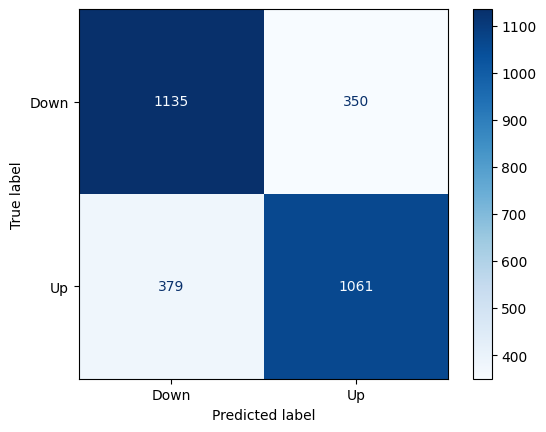

In [61]:
if BINARY_CLASSIFICATION:
    ConfusionMatrixDisplay.from_predictions(y_test.flatten(), y_pred, cmap='Blues', display_labels=["Down", "Up"])
else:
    print("Confusion matrix is not applicable for regression.")
    plt.figure(figsize=(12, 8))
    plt.plot(y_test.flatten(), label='True')
    plt.plot(y_pred.flatten()/10, label='Predicted')
    plt.legend()
    plt.show()

In [62]:
# Coverage model pred with bin_return_close
prob_coverage = overall_prob * classification_report(y_test.flatten(), y_pred, output_dict=True)['accuracy']
print("Coverage model accuracy based on bin_return_close:\n{:.3f}".format(prob_coverage))

Coverage model accuracy based on bin_return_close:
0.581


## Backtesting model


MODEL BACKTEST RESULTS
Epsilon:                      0.001
Number of observations:       2925
Number of bets:               792
Bet frequency:                0.2708 (27.08%)
----------------------------------------------------------------------
UP bets:                      340
DOWN bets:                    452
UP accuracy:                  0.5176
DOWN accuracy:                0.5553
----------------------------------------------------------------------
Confirmed bets:               3
Confirmed accuracy:           0.3333
Neutral-zone bets:            789
Neutral-zone accuracy:        0.5399
----------------------------------------------------------------------
Winning bets:                 427
Losing bets:                  365
Overall bet accuracy:         0.5391 (53.91%)
----------------------------------------------------------------------
Starting cash:                1000.00 USDT
Final cash:                   1620.00 USDT
Net profit:                   620.00 USDT
Total return:    

,Strategy,Number of Bets,Bet Accuracy,Final Cash,Total Return (%),Sharpe Ratio,Bankrupt
0,LSTM,792,0.5391,1620.0,62.0,4.2078,False
1,Momentum,2156,0.4768,0.0,-100.0,-1.5613,True
2,Random,792,0.4924,880.0,-12.0,-0.2663,False



FIRST MODEL BETS:


,previous_return,prediction,future_return,signal_type,decision,pnl_usd,cash
1,0.000545,0,0.001008,NEUTRAL,DOWN,-10.0,990.0
3,0.000213,0,-0.001296,NEUTRAL,DOWN,10.0,1000.0
6,-0.000565,1,-0.000817,NEUTRAL,UP,-10.0,990.0
7,-0.000817,1,0.001266,NEUTRAL,UP,10.0,1000.0
9,0.000764,0,0.002378,NEUTRAL,DOWN,-10.0,990.0
17,-0.000707,1,0.004264,NEUTRAL,UP,10.0,1000.0
20,-0.000309,1,0.000010,NEUTRAL,UP,10.0,1010.0
21,0.000010,0,-0.001587,NEUTRAL,DOWN,10.0,1020.0
24,0.000560,0,-0.009485,NEUTRAL,DOWN,10.0,1030.0
27,0.001941,1,-0.005124,CONFIRMED,UP,-10.0,1020.0


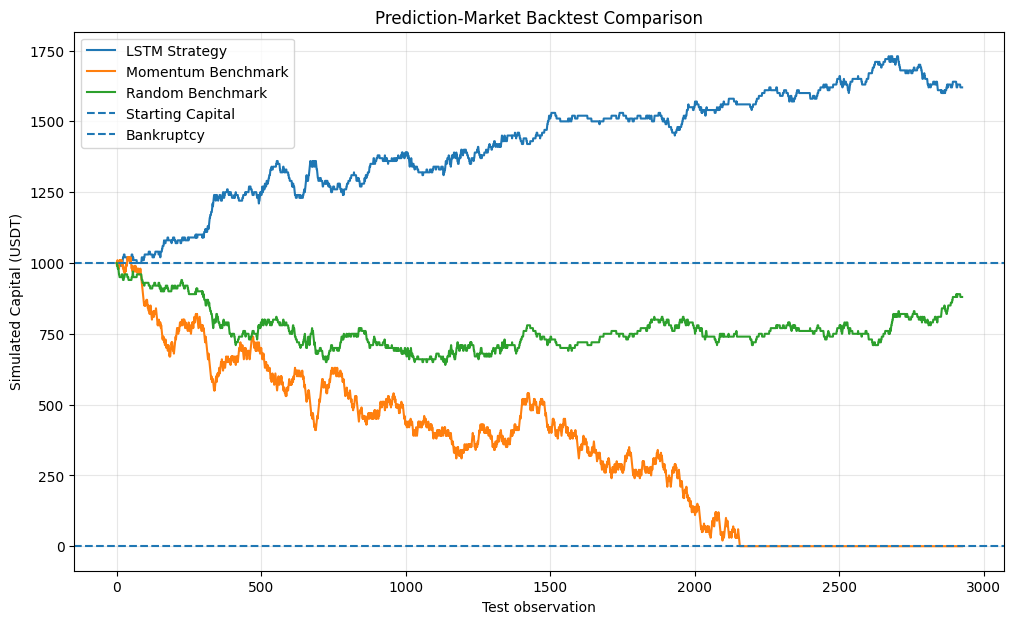

In [74]:
# ============================================================
# BACKTESTING - PREDICTION MARKET
# MODEL + MOMENTUM + RANDOM BENCHMARK
# ============================================================

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

EPSILON = 0.001

START_CASH = 1000.0
BET_PAYOUT = 10.0

RISK_FREE_ANNUAL = 0.0
RANDOM_SEED = 42


# ============================================================
# 1. PREPARE DATA
# ============================================================

predictions = np.asarray(y_pred).ravel().astype(int)

if not np.isin(predictions, [0, 1]).all():
    raise ValueError(
        "Predictions must contain only binary labels 0 and 1."
    )


# Original test returns before generate_lags()
returns = np.asarray(
    X_backtest["return_close"]
).ravel()


# For each prediction:
#
# previous_return = r[t]
# future_return   = r[t+1]
#
# First prediction is generated after LAGS_NUM observations.

previous_returns = returns[
    LAGS_NUM - 1:
    LAGS_NUM - 1 + len(predictions)
]

future_returns = returns[
    LAGS_NUM:
    LAGS_NUM + len(predictions)
]


if len(previous_returns) != len(predictions):
    raise ValueError(
        f"Previous return length mismatch: "
        f"{len(previous_returns)} vs {len(predictions)}"
    )

if len(future_returns) != len(predictions):
    raise ValueError(
        f"Future return length mismatch: "
        f"{len(future_returns)} vs {len(predictions)}"
    )


# ============================================================
# 2. MODEL STRATEGY
# ============================================================
#
# RULES:
#
# r[t] > EPSILON and prediction == 1
#       -> BET UP
#
# r[t] < -EPSILON and prediction == 0
#       -> BET DOWN
#
# |r[t]| <= EPSILON and prediction == 1
#       -> BET UP
#
# |r[t]| <= EPSILON and prediction == 0
#       -> BET DOWN
#
# Otherwise:
#       -> NO BET
#
# Settlement:
#
# UP wins   if r[t+1] > 0
# DOWN wins if r[t+1] < 0
#
# Bankruptcy:
#
# cash <= 0 -> stop betting permanently
# ============================================================

cash = START_CASH

cash_history = [cash]
pnl_history = []
decision_history = []
signal_type_history = []

bets = 0
wins = 0
losses = 0

up_bets = 0
down_bets = 0

up_wins = 0
down_wins = 0

confirmed_bets = 0
confirmed_wins = 0

neutral_bets = 0
neutral_wins = 0

bankrupt = False


for prediction, previous_return, future_return in zip(
    predictions,
    previous_returns,
    future_returns
):

    # --------------------------------------------------------
    # BANKRUPTCY
    # --------------------------------------------------------

    if bankrupt or cash <= 0:

        bankrupt = True

        pnl_history.append(0.0)
        decision_history.append("BANKRUPT")
        signal_type_history.append("BANKRUPT")

        cash_history.append(0.0)

        continue


    pnl = 0.0
    decision = "NO BET"
    signal_type = "NO BET"


    # --------------------------------------------------------
    # CLEARLY POSITIVE PREVIOUS RETURN + prediction = 1
    # -> UP
    # --------------------------------------------------------

    if previous_return > EPSILON and prediction == 1:

        decision = "UP"
        signal_type = "CONFIRMED"

        bets += 1
        confirmed_bets += 1
        up_bets += 1

        if future_return > 0:

            pnl = BET_PAYOUT

            wins += 1
            confirmed_wins += 1
            up_wins += 1

        else:

            pnl = -BET_PAYOUT
            losses += 1


    # --------------------------------------------------------
    # CLEARLY NEGATIVE PREVIOUS RETURN + prediction = 0
    # -> DOWN
    # --------------------------------------------------------

    elif previous_return < -EPSILON and prediction == 0:

        decision = "DOWN"
        signal_type = "CONFIRMED"

        bets += 1
        confirmed_bets += 1
        down_bets += 1

        if future_return < 0:

            pnl = BET_PAYOUT

            wins += 1
            confirmed_wins += 1
            down_wins += 1

        else:

            pnl = -BET_PAYOUT
            losses += 1


    # --------------------------------------------------------
    # NEUTRAL ZONE
    #
    # |r[t]| <= EPSILON
    #
    # prediction = 1 -> UP
    # prediction = 0 -> DOWN
    # --------------------------------------------------------

    elif abs(previous_return) <= EPSILON:

        signal_type = "NEUTRAL"

        bets += 1
        neutral_bets += 1


        # Prediction = 1 -> UP
        if prediction == 1:

            decision = "UP"
            up_bets += 1

            if future_return > 0:

                pnl = BET_PAYOUT

                wins += 1
                neutral_wins += 1
                up_wins += 1

            else:

                pnl = -BET_PAYOUT
                losses += 1


        # Prediction = 0 -> DOWN
        else:

            decision = "DOWN"
            down_bets += 1

            if future_return < 0:

                pnl = BET_PAYOUT

                wins += 1
                neutral_wins += 1
                down_wins += 1

            else:

                pnl = -BET_PAYOUT
                losses += 1


    # --------------------------------------------------------
    # NO BET
    # --------------------------------------------------------

    else:

        pnl = 0.0


    # --------------------------------------------------------
    # BANKRUPTCY PROTECTION
    # --------------------------------------------------------
    #
    # Strategy cannot lose more money than currently available.
    #

    if pnl < 0:

        pnl = -min(
            abs(pnl),
            cash
        )


    cash += pnl

    cash = max(
        cash,
        0.0
    )


    if cash <= 0:
        bankrupt = True


    pnl_history.append(pnl)
    decision_history.append(decision)
    signal_type_history.append(signal_type)

    cash_history.append(cash)


# ============================================================
# 3. MODEL STATISTICS
# ============================================================

number_of_observations = len(predictions)

bet_frequency = (
    bets / number_of_observations
    if number_of_observations > 0
    else np.nan
)

bet_accuracy = (
    wins / bets
    if bets > 0
    else np.nan
)

up_accuracy = (
    up_wins / up_bets
    if up_bets > 0
    else np.nan
)

down_accuracy = (
    down_wins / down_bets
    if down_bets > 0
    else np.nan
)

confirmed_accuracy = (
    confirmed_wins / confirmed_bets
    if confirmed_bets > 0
    else np.nan
)

neutral_accuracy = (
    neutral_wins / neutral_bets
    if neutral_bets > 0
    else np.nan
)

net_profit = (
    cash - START_CASH
)

total_return = (
    net_profit / START_CASH
) * 100


# ============================================================
# 4. SHARPE RATIO FUNCTION
# ============================================================

periods_per_year = (
    (365 * 24 * 60 * 60 * 1000)
    / TIMEFRAME_DICT[TIMEFRAME]
)


def annualized_sharpe(
    equity,
    periods_per_year,
    risk_free_annual=0.0
):

    equity = np.asarray(
        equity,
        dtype=float
    )

    if len(equity) < 3:
        return np.nan

    if not np.isfinite(equity).all():
        return np.nan

    # Calculate returns only while capital is positive
    valid_returns = []

    for previous_cash, current_cash in zip(
        equity[:-1],
        equity[1:]
    ):

        if previous_cash <= 0:
            break

        valid_returns.append(
            (current_cash - previous_cash)
            / previous_cash
        )


    returns_array = np.asarray(
        valid_returns,
        dtype=float
    )


    if len(returns_array) < 2:
        return np.nan


    risk_free_per_period = np.expm1(
        np.log1p(risk_free_annual)
        / periods_per_year
    )


    excess_returns = (
        returns_array
        - risk_free_per_period
    )


    volatility = excess_returns.std(
        ddof=1
    )


    if np.isclose(
        volatility,
        0.0
    ):
        return np.nan


    return (
        np.sqrt(periods_per_year)
        * excess_returns.mean()
        / volatility
    )


strategy_sharpe = annualized_sharpe(
    cash_history,
    periods_per_year,
    RISK_FREE_ANNUAL
)


# ============================================================
# 5. MOMENTUM BENCHMARK
# ============================================================
#
# No model is used.
#
# r[t] > 0 -> UP
# r[t] < 0 -> DOWN
#
# Bankruptcy at 0 USDT.
# ============================================================

momentum_cash = START_CASH

momentum_cash_history = [
    momentum_cash
]

momentum_bets = 0
momentum_wins = 0
momentum_losses = 0

momentum_bankrupt = False


for previous_return, future_return in zip(
    previous_returns,
    future_returns
):

    # --------------------------------------------------------
    # BANKRUPTCY
    # --------------------------------------------------------

    if momentum_bankrupt or momentum_cash <= 0:

        momentum_bankrupt = True

        momentum_cash_history.append(
            0.0
        )

        continue


    pnl = 0.0


    # --------------------------------------------------------
    # MOMENTUM UP
    # --------------------------------------------------------

    if previous_return > 0:

        momentum_bets += 1

        if future_return > 0:

            pnl = BET_PAYOUT
            momentum_wins += 1

        else:

            pnl = -BET_PAYOUT
            momentum_losses += 1


    # --------------------------------------------------------
    # MOMENTUM DOWN
    # --------------------------------------------------------

    elif previous_return < 0:

        momentum_bets += 1

        if future_return < 0:

            pnl = BET_PAYOUT
            momentum_wins += 1

        else:

            pnl = -BET_PAYOUT
            momentum_losses += 1


    # --------------------------------------------------------
    # EXACTLY ZERO -> NO BET
    # --------------------------------------------------------

    else:

        pnl = 0.0


    # --------------------------------------------------------
    # BANKRUPTCY PROTECTION
    # --------------------------------------------------------

    if pnl < 0:

        pnl = -min(
            abs(pnl),
            momentum_cash
        )


    momentum_cash += pnl

    momentum_cash = max(
        momentum_cash,
        0.0
    )


    if momentum_cash <= 0:
        momentum_bankrupt = True


    momentum_cash_history.append(
        momentum_cash
    )


momentum_accuracy = (
    momentum_wins / momentum_bets
    if momentum_bets > 0
    else np.nan
)

momentum_return = (
    (momentum_cash - START_CASH)
    / START_CASH
) * 100


momentum_sharpe = annualized_sharpe(
    momentum_cash_history,
    periods_per_year,
    RISK_FREE_ANNUAL
)


# ============================================================
# 6. RANDOM BENCHMARK
# ============================================================
#
# Random strategy bets only when the MODEL strategy
# would place a bet.
#
# Random direction:
#
# 1 -> UP
# 0 -> DOWN
#
# Fixed seed ensures reproducibility.
#
# Bankruptcy at 0 USDT.
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)

random_cash = START_CASH

random_cash_history = [
    random_cash
]

random_bets = 0
random_wins = 0
random_losses = 0

random_bankrupt = False


for model_decision, future_return in zip(
    decision_history,
    future_returns
):

    # --------------------------------------------------------
    # BANKRUPTCY
    # --------------------------------------------------------

    if random_bankrupt or random_cash <= 0:

        random_bankrupt = True

        random_cash_history.append(
            0.0
        )

        continue


    pnl = 0.0


    # --------------------------------------------------------
    # RANDOM BET
    # --------------------------------------------------------

    if model_decision in ["UP", "DOWN"]:

        random_bets += 1

        random_prediction = rng.integers(
            0,
            2
        )


        # Random UP
        if random_prediction == 1:

            if future_return > 0:

                pnl = BET_PAYOUT
                random_wins += 1

            else:

                pnl = -BET_PAYOUT
                random_losses += 1


        # Random DOWN
        else:

            if future_return < 0:

                pnl = BET_PAYOUT
                random_wins += 1

            else:

                pnl = -BET_PAYOUT
                random_losses += 1


    # --------------------------------------------------------
    # NO BET
    # --------------------------------------------------------

    else:

        pnl = 0.0


    # --------------------------------------------------------
    # BANKRUPTCY PROTECTION
    # --------------------------------------------------------

    if pnl < 0:

        pnl = -min(
            abs(pnl),
            random_cash
        )


    random_cash += pnl

    random_cash = max(
        random_cash,
        0.0
    )


    if random_cash <= 0:
        random_bankrupt = True


    random_cash_history.append(
        random_cash
    )


random_accuracy = (
    random_wins / random_bets
    if random_bets > 0
    else np.nan
)

random_return = (
    (random_cash - START_CASH)
    / START_CASH
) * 100


random_sharpe = annualized_sharpe(
    random_cash_history,
    periods_per_year,
    RISK_FREE_ANNUAL
)


# ============================================================
# 7. DETAILED MODEL RESULTS
# ============================================================

print()
print("=" * 70)
print("MODEL BACKTEST RESULTS")
print("=" * 70)

print(
    f"Epsilon:                      "
    f"{EPSILON}"
)

print(
    f"Number of observations:       "
    f"{number_of_observations}"
)

print(
    f"Number of bets:               "
    f"{bets}"
)

print(
    f"Bet frequency:                "
    f"{bet_frequency:.4f} "
    f"({bet_frequency * 100:.2f}%)"
)

print("-" * 70)

print(
    f"UP bets:                      "
    f"{up_bets}"
)

print(
    f"DOWN bets:                    "
    f"{down_bets}"
)

print(
    f"UP accuracy:                  "
    f"{up_accuracy:.4f}"
)

print(
    f"DOWN accuracy:                "
    f"{down_accuracy:.4f}"
)

print("-" * 70)

print(
    f"Confirmed bets:               "
    f"{confirmed_bets}"
)

print(
    f"Confirmed accuracy:           "
    f"{confirmed_accuracy:.4f}"
)

print(
    f"Neutral-zone bets:            "
    f"{neutral_bets}"
)

print(
    f"Neutral-zone accuracy:        "
    f"{neutral_accuracy:.4f}"
)

print("-" * 70)

print(
    f"Winning bets:                 "
    f"{wins}"
)

print(
    f"Losing bets:                  "
    f"{losses}"
)

print(
    f"Overall bet accuracy:         "
    f"{bet_accuracy:.4f} "
    f"({bet_accuracy * 100:.2f}%)"
)

print("-" * 70)

print(
    f"Starting cash:                "
    f"{START_CASH:.2f} USDT"
)

print(
    f"Final cash:                   "
    f"{cash:.2f} USDT"
)

print(
    f"Net profit:                   "
    f"{net_profit:.2f} USDT"
)

print(
    f"Total return:                 "
    f"{total_return:.2f}%"
)

print(
    f"Sharpe ratio:                 "
    f"{strategy_sharpe:.4f}"
)

print(
    f"Bankrupt:                     "
    f"{bankrupt}"
)

print("=" * 70)


# ============================================================
# 8. COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "Strategy": [
        "LSTM",
        "Momentum",
        "Random"
    ],

    "Number of Bets": [
        bets,
        momentum_bets,
        random_bets
    ],

    "Bet Accuracy": [
        bet_accuracy,
        momentum_accuracy,
        random_accuracy
    ],

    "Final Cash": [
        cash,
        momentum_cash,
        random_cash
    ],

    "Total Return (%)": [
        total_return,
        momentum_return,
        random_return
    ],

    "Sharpe Ratio": [
        strategy_sharpe,
        momentum_sharpe,
        random_sharpe
    ],

    "Bankrupt": [
        bankrupt,
        momentum_bankrupt,
        random_bankrupt
    ]

})


comparison_display = comparison.copy()

comparison_display["Bet Accuracy"] = (
    comparison_display["Bet Accuracy"]
    .round(4)
)

comparison_display["Final Cash"] = (
    comparison_display["Final Cash"]
    .round(2)
)

comparison_display["Total Return (%)"] = (
    comparison_display["Total Return (%)"]
    .round(2)
)

comparison_display["Sharpe Ratio"] = (
    comparison_display["Sharpe Ratio"]
    .round(4)
)


print()
print("=" * 80)
print("BACKTEST COMPARISON")
print("=" * 80)

display(
    comparison_display
)


# ============================================================
# 9. DETAILED RESULTS DATAFRAME
# ============================================================

backtest_results = pd.DataFrame({

    "previous_return": previous_returns,

    "prediction": predictions,

    "future_return": future_returns,

    "signal_type": signal_type_history,

    "decision": decision_history,

    "pnl_usd": pnl_history,

    "cash": cash_history[1:]

})


print()
print("FIRST MODEL BETS:")

display(
    backtest_results[
        backtest_results["decision"].isin(
            ["UP", "DOWN"]
        )
    ].head(20)
)


# ============================================================
# 10. EQUITY CURVES
# ============================================================

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    cash_history,
    label="LSTM Strategy"
)

plt.plot(
    momentum_cash_history,
    label="Momentum Benchmark"
)

plt.plot(
    random_cash_history,
    label="Random Benchmark"
)

plt.axhline(
    y=START_CASH,
    linestyle="--",
    label="Starting Capital"
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Bankruptcy"
)

plt.xlabel(
    "Test observation"
)

plt.ylabel(
    "Simulated Capital (USDT)"
)

plt.title(
    "Prediction-Market Backtest Comparison"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()